# MC Likelihood Fit (negative binomial)

Fit the MC simulated histogram to the analytic theory curve using the negative binomial likelihood from `gas_likelihood_fit.py`.

Theory curve computed identically to `gen_signal_model_mc.py`: `dgamma_dp_tot_noneq` → `get_drdqz`, with `alpha=0.9`, `T_sensor=293.05 K`, `T_gas=293 K`, `sphere_radius=50 nm`, gas=Xe.

In [27]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import matplotlib.pyplot as plt
import calc_gas_collision_spectrum as calc_gas
import gas_likelihood_fit as glf

import importlib
# importlib.reload(utils)
importlib.reload(calc_gas)
importlib.reload(glf)

<module 'gas_likelihood_fit' from '/Users/yuhan/work/nanospheres/gas_collisiions/analysis_notebooks/sphere_20260215_final_analysis/../../gas_likelihood_fit.py'>

In [28]:
# ── Configuration ─────────────────────────────────────────────────────────
fit_band = (200, 800)  # keV/c — adjust here

# Systematic uncertainty: fractional uncertainty per bin → negbin k
frac_uncertainty = 0.05  # systematic uncertainty per bin
k_negbin = 1.0 / frac_uncertainty**2  # k = 1/f^2

# Amplitude scale nuisance parameter (Gaussian constraint)
amp_scale_sigma = 0.10  # 10% uncertainty on amplitude calibration

# chi2 acceptance fraction per threshold — fill in measured values
eff_chi2_by_thr = {
    300:  0.60,
    600:  0.95,
    1000: 0.99,
    1500: 1.00,
    2000: 1.00,
}

# Data files
mc_file     = '../../data_processed/gas_recon/mc_xe_chi2_scan.h5py'
signal_file = '../../data_processed/gas_signal/xe_signal_5e-08nm_1e-08mbar.npz'

# Load MC histogram at 1e-7 mbar (using chi2=600 as reference for single-fit cell)
bc, mc_pressures, mc_meta = glf.load_mc_hists(mc_file, chi2_thr=600)

target_pressure = 1e-7
hist = mc_pressures[target_pressure]

print(f'Fractional systematic uncertainty: {frac_uncertainty:.1%}')
print(f'k_negbin = 1/{frac_uncertainty}^2 = {k_negbin:.1f}')
print(f'amp_scale_sigma = {amp_scale_sigma}')
print(f'MC histogram: p={target_pressure:.1e} mbar, total counts={hist.sum():.0f}')
print(f'MC params: alpha={mc_meta["mc_alpha"]}, T_sensor={mc_meta["mc_T_sensor"]}, '
      f'T_gas={mc_meta["mc_T_gas"]}, gas={mc_meta["mc_gas"]}')
print(f'Fit band: {fit_band} keV/c')
print(f'eff_chi2 by threshold: {eff_chi2_by_thr}')

Fractional systematic uncertainty: 5.0%
k_negbin = 1/0.05^2 = 400.0
amp_scale_sigma = 0.1
MC histogram: p=1.0e-07 mbar, total counts=913158
MC params: alpha=0.9, T_sensor=293.05, T_gas=293, gas=xe
Fit band: (200, 800) keV/c
eff_chi2 by threshold: {300: 0.6, 600: 0.95, 1000: 0.99, 1500: 1.0, 2000: 1.0}


In [20]:
# Compute theory curve — same model as gen_signal_model_mc.py
sphere_radius = 50e-9  # m
gas = 'xe'
mg_amu = 131.293
alpha = mc_meta['mc_alpha']       # 0.9
T_gas = mc_meta['mc_T_gas']       # 293
T_sensor = mc_meta['mc_T_sensor'] # 293.05

# Same qq grid as gen_signal_model_mc.py
qq_kev = np.linspace(0.5, 2000, 2000)

# Theory spectrum at 1e-8 mbar reference (same as gen_signal_model_mc.py)
drdq_unit = calc_gas.dgamma_dp_tot_noneq(
    qq_kev, mg_amu, p_mbar=1e-8, alpha=alpha,
    T_gas=T_gas, T_sensor=T_sensor, sphere_radius=sphere_radius,
)
_, drdqz_unit = calc_gas.get_drdqz(qq_kev, drdq_unit)

print(f'Theory: alpha={alpha}, T_sensor={T_sensor}, T_gas={T_gas}')
print(f'Rate @ 1e-8 mbar: {np.trapz(drdqz_unit, qq_kev):.3f} Hz')

Theory: alpha=0.9, T_sensor=293.05, T_gas=293
Rate @ 1e-8 mbar: 420.178 Hz


In [21]:
# Interpolate theory drdqz onto histogram bin centres
drdqz_bc = np.interp(bc, qq_kev, drdqz_unit)

# Negative binomial fit
nll_nb, params_nb = glf.minimize_nll_negbin(
    drdqz_bc, bc, hist,
    glf.eff_coefs, glf.eff_chi2, fit_band,
    k_negbin, glf.nll_offset
)
sigma_nb, log10_p_nb = params_nb

# GOF
p_scale_nb = 10**(log10_p_nb - (-8))
_, drdqzn_nb = calc_gas.smear_drdqz_gauss(bc, drdqz_bc, sigma_nb)
mu_nb, idx_fit = glf.build_model_counts(
    sigma_nb, drdqzn_nb * p_scale_nb, bc, hist, glf.eff_coefs, glf.eff_chi2, fit_band)
gof_chi2_nb, gof_ndof_nb, gof_chi2_ndf_nb, gof_pval_nb = glf.calc_gof(mu_nb, hist[idx_fit], nparams=2, k=k_negbin)

print(f'=== Negative binomial fit (k={k_negbin:.0f}, f={frac_uncertainty:.1%}) ===')
print(f'  sigma     = {sigma_nb:.2f} keV/c')
print(f'  log10(p)  = {log10_p_nb:.4f}  ->  p = {10**log10_p_nb:.3e} mbar')
print(f'  NLL       = {nll_nb:.2f}')
print(f'  GOF: chi2/ndf = {gof_chi2_ndf_nb:.3f} ({gof_ndof_nb} dof), p-val = {gof_pval_nb:.4f}')

# Poisson fit for comparison
nll_pois, params_pois = glf.minimize_nll(
    drdqz_bc, bc, hist,
    glf.eff_coefs, glf.eff_chi2, fit_band, glf.nll_offset
)
sigma_pois, log10_p_pois = params_pois

print(f'\n=== Poisson fit ===')
print(f'  sigma     = {sigma_pois:.2f} keV/c')
print(f'  log10(p)  = {log10_p_pois:.4f}  ->  p = {10**log10_p_pois:.3e} mbar')
print(f'  NLL       = {nll_pois:.2f}')
print(f'\n  True p    = {target_pressure:.1e} mbar  (log10 = {np.log10(target_pressure):.2f})')

=== Negative binomial fit (k=400, f=5.0%) ===
  sigma     = 76.66 keV/c
  log10(p)  = -7.5501  ->  p = 2.818e-08 mbar
  NLL       = 55.05
  GOF: chi2/ndf = 0.832 (11 dof), p-val = 0.6079

=== Poisson fit ===
  sigma     = 73.40 keV/c
  log10(p)  = -7.4440  ->  p = 3.598e-08 mbar
  NLL       = -243619.48

  True p    = 1.0e-07 mbar  (log10 = -7.00)


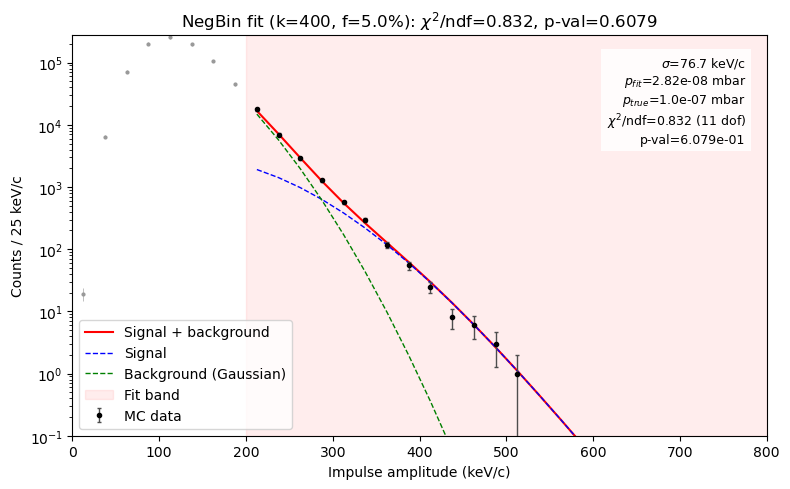

In [22]:
# Plot: data histogram vs best-fit model
fig, ax = plt.subplots(figsize=(8, 5))

bc_fit = bc[idx_fit]
dq = bc[1] - bc[0]

n_full = hist.astype(float)
err_full = np.sqrt(n_full + n_full**2 / k_negbin)
n_fit = hist[idx_fit].astype(float)
err_fit = np.sqrt(n_fit + n_fit**2 / k_negbin)

ax.errorbar(bc, n_full, yerr=err_full, fmt='none', ecolor='0.75', elinewidth=0.7, capsize=0)
ax.plot(bc, n_full, 'o', ms=2, color='0.6')
ax.errorbar(bc_fit, n_fit, yerr=err_fit, fmt='o', ms=3, color='k',
            ecolor='0.3', elinewidth=1, capsize=1.5, label='MC data', zorder=5)

_, drdqzn_fit = calc_gas.smear_drdqz_gauss(bc, drdqz_bc, sigma_nb)
pressure_scale = 10**(log10_p_nb - (-8))
hist_norm = np.sum(hist) * glf.length_search_window * dq
eff_qq = glf.func_eff(bc, *glf.eff_coefs)
hist_gas = glf.eff_chi2 * eff_qq * drdqzn_fit * pressure_scale * hist_norm

gas_contribution = np.sum(hist_gas[idx_fit])
ntot = np.sum(n_fit) - gas_contribution
if ntot > 0:
    bkg_fit = ntot * glf.gaus_normalized(bc_fit, 0, sigma_nb, fit_band) * dq
else:
    bkg_fit = np.zeros_like(bc_fit)

ax.plot(bc_fit, hist_gas[idx_fit] + bkg_fit, 'r-', lw=1.5, label='Signal + background')
ax.plot(bc_fit, hist_gas[idx_fit], 'b--', lw=1, label='Signal')
ax.plot(bc_fit, bkg_fit, 'g--', lw=1, label='Background (Gaussian)')
ax.axvspan(fit_band[0], fit_band[1], alpha=0.07, color='red', label='Fit band')

ax.text(0.97, 0.95,
        f'$\\sigma$={sigma_nb:.1f} keV/c\n'
        f'$p_{{fit}}$={10**log10_p_nb:.2e} mbar\n$p_{{true}}$={target_pressure:.1e} mbar\n'
        f'$\\chi^2$/ndf={gof_chi2_ndf_nb:.3f} ({gof_ndof_nb} dof)\np-val={gof_pval_nb:.3e}',
        transform=ax.transAxes, va='top', ha='right', fontsize=9,
        bbox=dict(fc='white', alpha=0.85, ec='none'))

ax.set_ylim(1e-1)
ax.set_xlabel('Impulse amplitude (keV/c)')
ax.set_ylabel('Counts / 25 keV/c')
ax.set_xlim(0, 800)
ax.set_yscale('log')
ax.legend(loc=3)
ax.set_title(f'NegBin fit (k={k_negbin:.0f}, f={frac_uncertainty:.1%}): '
             f'$\\chi^2$/ndf={gof_chi2_ndf_nb:.3f}, p-val={gof_pval_nb:.4f}')
plt.tight_layout()

#### Perform a simple 2-D likelihood scan

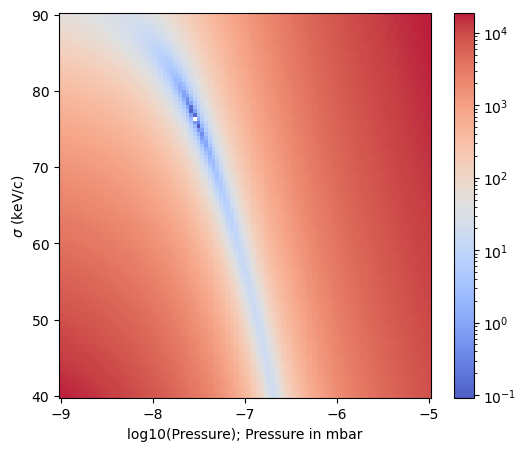

In [23]:
from matplotlib.colors import LogNorm

log10_p_list = np.linspace(-9, -5, 100)
sigma_list = np.linspace(40, 90, 100)

nll_all = np.empty((log10_p_list.size, sigma_list.size))
for i, log10_p in enumerate(log10_p_list):
    for j, sigma in enumerate(sigma_list):
        nll_all[i, j] = glf.nll_sigma_pressure_negbin(sigma, log10_p, drdqz_bc, bc, hist, glf.eff_coefs, glf.eff_chi2, fit_band, k_negbin)

X, Y = np.meshgrid(log10_p_list, sigma_list)

fig, ax = plt.subplots(figsize=(6, 5))
heatmap = ax.pcolormesh(X, Y, nll_all.T - np.min(nll_all), norm=LogNorm(), cmap='coolwarm', edgecolor='none', alpha=0.9)

ax.set_xlabel('log10(Pressure); Pressure in mbar')
ax.set_ylabel(r'$\sigma$ (keV/c)')
fig.colorbar(heatmap)

## Multi-pressure scan: all chi2 thresholds x all pressures

Three fit configurations run over the same (chi2_threshold, pressure) grid:
- **Floating sigma**: fits (sigma, log10_p), with Gaussian background
- **Fixed sigma**: fixes sigma=60 keV/c, fits log10_p only, with Gaussian background
- **Signal-only**: fits (sigma, log10_p, amp_scale) with no background, fit band starts at 300 keV/c

In [31]:
from scipy.optimize import minimize_scalar

chi2_thresholds = sorted(eff_chi2_by_thr.keys())
fit_band_sigonly = (300, 800)
sigma_fixed = 60.0  # keV/c

# Build interpolator for floating alpha / T_sensor fit
drdqz_interp, qq_kev_grid, alpha_bounds, ts_bounds = glf.make_drdqz_interpolator(signal_file)
print(f'Interpolator: alpha {alpha_bounds}, T_sensor {ts_bounds} K')

# ── Helper: run one fit configuration across all (chi2_thr, pressure) ─────
def run_scan(config_name, chi2_thresholds, eff_chi2_by_thr, mc_file, drdqz_bc,
             qq_kev, drdqz_unit, fit_band, k_negbin, sigma_fixed=60.0,
             amp_scale_sigma=None, fit_band_sigonly=(300, 800),
             drdqz_interp=None, qq_kev_grid=None,
             alpha_bounds=(0.0, 1.0), ts_bounds=(294.0, 1000.0)):
    """Returns dict keyed by (chi2_thr, pressure) with standardised result dicts."""
    results = {}
    for chi2_thr in chi2_thresholds:
        eff_chi2 = eff_chi2_by_thr[chi2_thr]
        bc_thr, mc_p_thr, _ = glf.load_mc_hists(mc_file, chi2_thr=chi2_thr)
        pressures = sorted([p for p in mc_p_thr.keys() if p > 0])

        for p in pressures:
            h = mc_p_thr[p]
            alpha_fit = np.nan
            T_sensor_fit = np.nan

            if config_name == 'floating_sigma':
                nll, params = glf.minimize_nll_negbin(
                    drdqz_bc, bc_thr, h, glf.eff_coefs, eff_chi2, fit_band, k_negbin, glf.nll_offset)
                sigma, log10_p = params
                amp_scale = 1.0
                nparams = 2
                band = fit_band
                signal_only = False

            elif config_name == 'fixed_sigma':
                drdqz_bc_thr = np.interp(bc_thr, qq_kev, drdqz_unit)
                res = minimize_scalar(
                    lambda lp: glf.nll_sigma_pressure_negbin(
                        sigma_fixed, lp, drdqz_bc_thr, bc_thr, h,
                        glf.eff_coefs, eff_chi2, fit_band, k_negbin, glf.nll_offset),
                    bounds=(-13, -5), method='bounded')
                sigma = sigma_fixed
                log10_p = res.x
                nll = res.fun
                amp_scale = 1.0
                nparams = 1
                band = fit_band
                signal_only = False

            elif config_name == 'signal_only':
                nll, params = glf.minimize_nll_negbin(
                    drdqz_bc, bc_thr, h, glf.eff_coefs, eff_chi2, fit_band_sigonly,
                    k_negbin, glf.nll_offset, signal_only=True, amp_scale_sigma=amp_scale_sigma)
                sigma, log10_p, amp_scale = params
                nparams = 3
                band = fit_band_sigonly
                signal_only = True

            elif config_name == 'full_fit':
                nll, params = glf.minimize_nll_full(
                    drdqz_interp, qq_kev_grid, bc_thr, h,
                    glf.eff_coefs, eff_chi2, fit_band,
                    k=k_negbin, nll_offset=glf.nll_offset,
                    alpha_bounds=alpha_bounds, ts_bounds=ts_bounds)
                sigma, log10_p, alpha_fit, T_sensor_fit = params
                amp_scale = 1.0
                nparams = 4
                band = fit_band
                signal_only = False
                drdqz_bc = np.interp(bc_thr, qq_kev_grid, drdqz_interp((alpha_fit, T_sensor_fit)))

            elif config_name == 'full_fit_sigonly':
                nll, params = glf.minimize_nll_full(
                    drdqz_interp, qq_kev_grid, bc_thr, h,
                    glf.eff_coefs, eff_chi2, fit_band_sigonly,
                    k=k_negbin, nll_offset=glf.nll_offset,
                    signal_only=True, amp_scale_sigma=amp_scale_sigma,
                    alpha_bounds=alpha_bounds, ts_bounds=ts_bounds)
                sigma, log10_p, alpha_fit, T_sensor_fit, amp_scale = params
                nparams = 5
                band = fit_band_sigonly
                signal_only = True
                drdqz_bc = np.interp(bc_thr, qq_kev_grid, drdqz_interp((alpha_fit, T_sensor_fit)))

            # GOF
            p_scale = 10**(log10_p - (-8))
            if amp_scale != 1.0:
                drdqz_s = np.interp(bc_thr / amp_scale, bc_thr, drdqz_bc) / amp_scale
            else:
                drdqz_s = drdqz_bc
            _, drdqzn = calc_gas.smear_drdqz_gauss(bc_thr, drdqz_s, sigma)
            mu_fit, idx_f = glf.build_model_counts(
                sigma, drdqzn * p_scale, bc_thr, h, glf.eff_coefs, eff_chi2, band, signal_only=signal_only)
            gof = glf.calc_gof(mu_fit, h[idx_f], nparams=nparams, k=k_negbin)

            # Reset drdqz_bc to reference curve for next iteration
            if config_name in ('full_fit', 'full_fit_sigonly'):
                drdqz_bc = np.interp(bc_thr, qq_kev, drdqz_unit)

            results[(chi2_thr, p)] = {
                'sigma': sigma, 'log10_p': log10_p, 'nll': nll,
                'amp_scale': amp_scale, 'alpha': alpha_fit, 'T_sensor': T_sensor_fit,
                'hist': h, 'eff_chi2': eff_chi2,
                'fit_band': band, 'signal_only': signal_only,
                'gof_chi2': gof[0], 'gof_ndof': gof[1],
                'gof_chi2_ndf': gof[2], 'gof_pval': gof[3],
            }
        print(f'  chi2<{chi2_thr} (eff_chi2={eff_chi2}): {len(pressures)} pressures')
    return results

# ── Run all scan configurations ────────────────────────────────────────────
scan_configs = {
    'floating_sigma':   'Floating $\\sigma$',
    'fixed_sigma':      f'Fixed $\\sigma$={sigma_fixed:.0f} keV/c',
    'signal_only':      'Signal-only (no bkg)',
    'full_fit':         'Full fit ($\\alpha$, $T_s$ float)',
    'full_fit_sigonly': 'Full fit, signal-only',
}

all_results = {}
for cfg_name, cfg_label in scan_configs.items():
    print(f'\n{cfg_label}:')
    all_results[cfg_name] = run_scan(
        cfg_name, chi2_thresholds, eff_chi2_by_thr, mc_file, drdqz_bc,
        qq_kev, drdqz_unit, fit_band, k_negbin, sigma_fixed,
        amp_scale_sigma=amp_scale_sigma, fit_band_sigonly=fit_band_sigonly,
        drdqz_interp=drdqz_interp, qq_kev_grid=qq_kev_grid,
        alpha_bounds=alpha_bounds, ts_bounds=ts_bounds)

all_pressures = sorted({p for _, p in all_results['floating_sigma'].keys()})
print(f'\nTotal fits per config: {len(all_results["floating_sigma"])}')
print(f'Pressures: {[f"{p:.0e}" for p in all_pressures]}')

Interpolator: alpha (0.0, 1.0), T_sensor (294.0, 1000.0) K

Floating $\sigma$:
  chi2<300 (eff_chi2=0.6): 9 pressures
  chi2<600 (eff_chi2=0.95): 9 pressures
  chi2<1000 (eff_chi2=0.99): 9 pressures
  chi2<1500 (eff_chi2=1.0): 9 pressures
  chi2<2000 (eff_chi2=1.0): 9 pressures

Fixed $\sigma$=60 keV/c:
  chi2<300 (eff_chi2=0.6): 9 pressures
  chi2<600 (eff_chi2=0.95): 9 pressures
  chi2<1000 (eff_chi2=0.99): 9 pressures
  chi2<1500 (eff_chi2=1.0): 9 pressures
  chi2<2000 (eff_chi2=1.0): 9 pressures

Signal-only (no bkg):
  chi2<300 (eff_chi2=0.6): 9 pressures
  chi2<600 (eff_chi2=0.95): 9 pressures
  chi2<1000 (eff_chi2=0.99): 9 pressures
  chi2<1500 (eff_chi2=1.0): 9 pressures
  chi2<2000 (eff_chi2=1.0): 9 pressures

Full fit ($\alpha$, $T_s$ float):
  chi2<300 (eff_chi2=0.6): 9 pressures
  chi2<600 (eff_chi2=0.95): 9 pressures
  chi2<1000 (eff_chi2=0.99): 9 pressures
  chi2<1500 (eff_chi2=1.0): 9 pressures
  chi2<2000 (eff_chi2=1.0): 9 pressures

Full fit, signal-only:
  chi2<300 (e

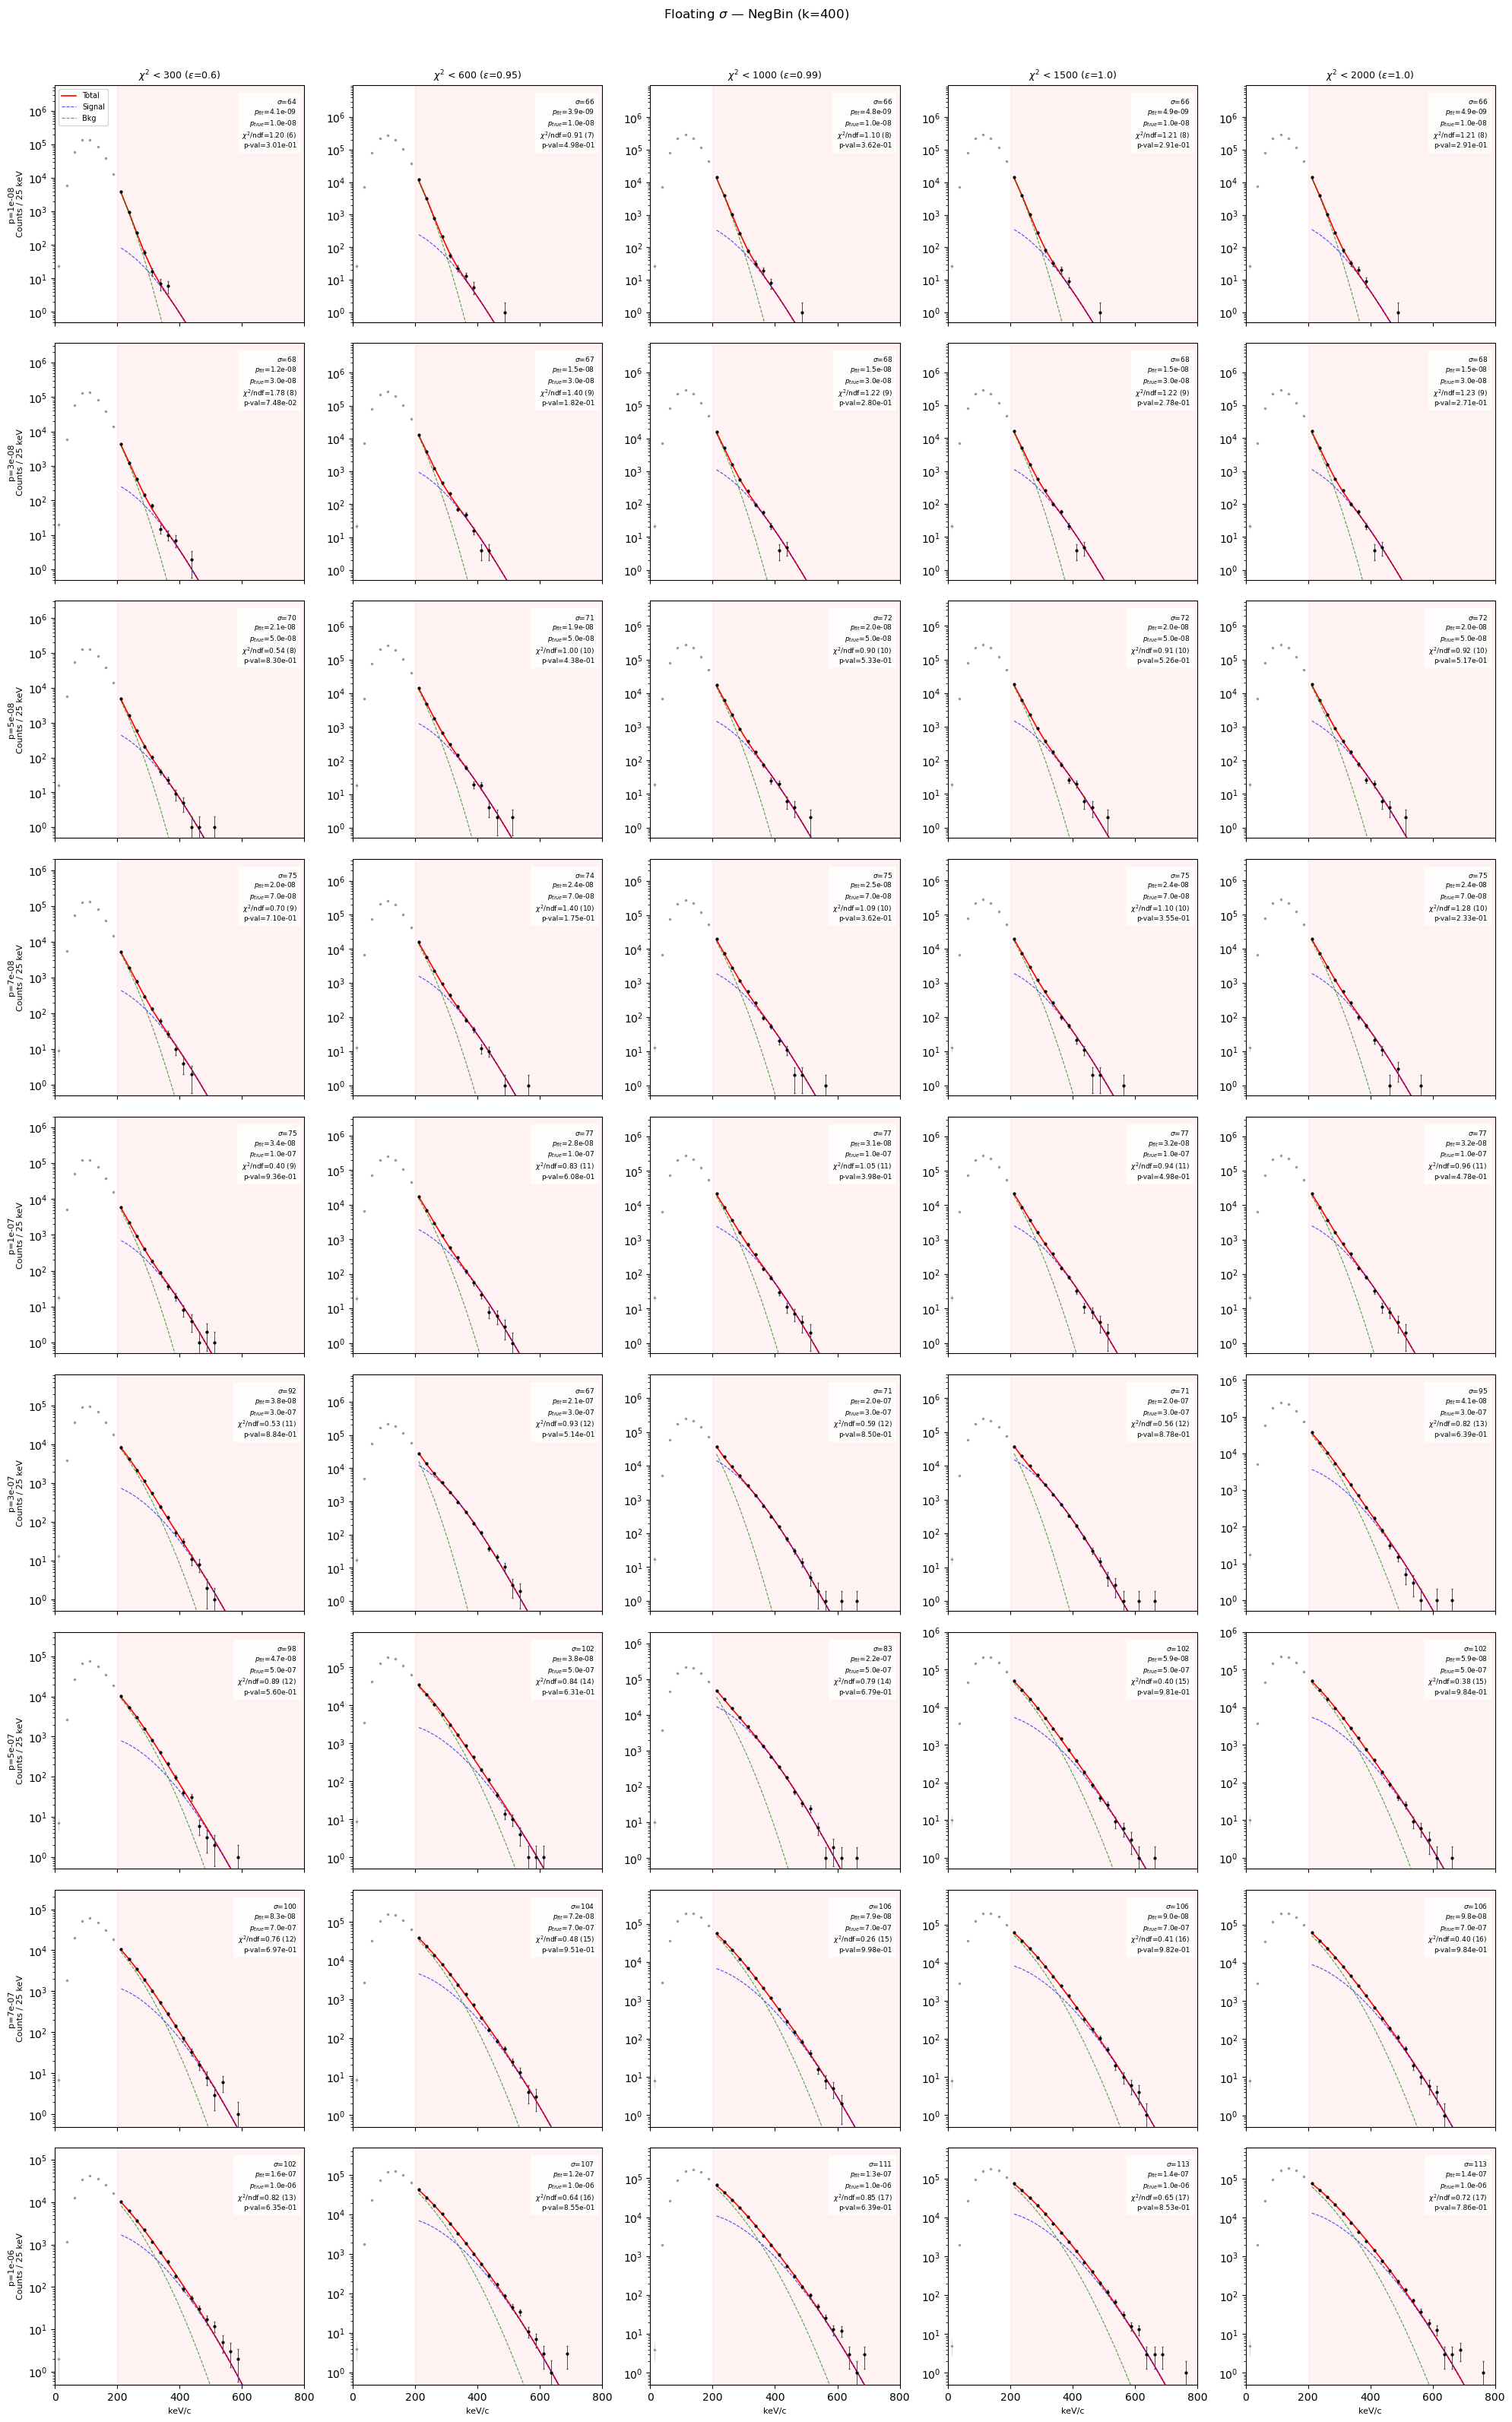

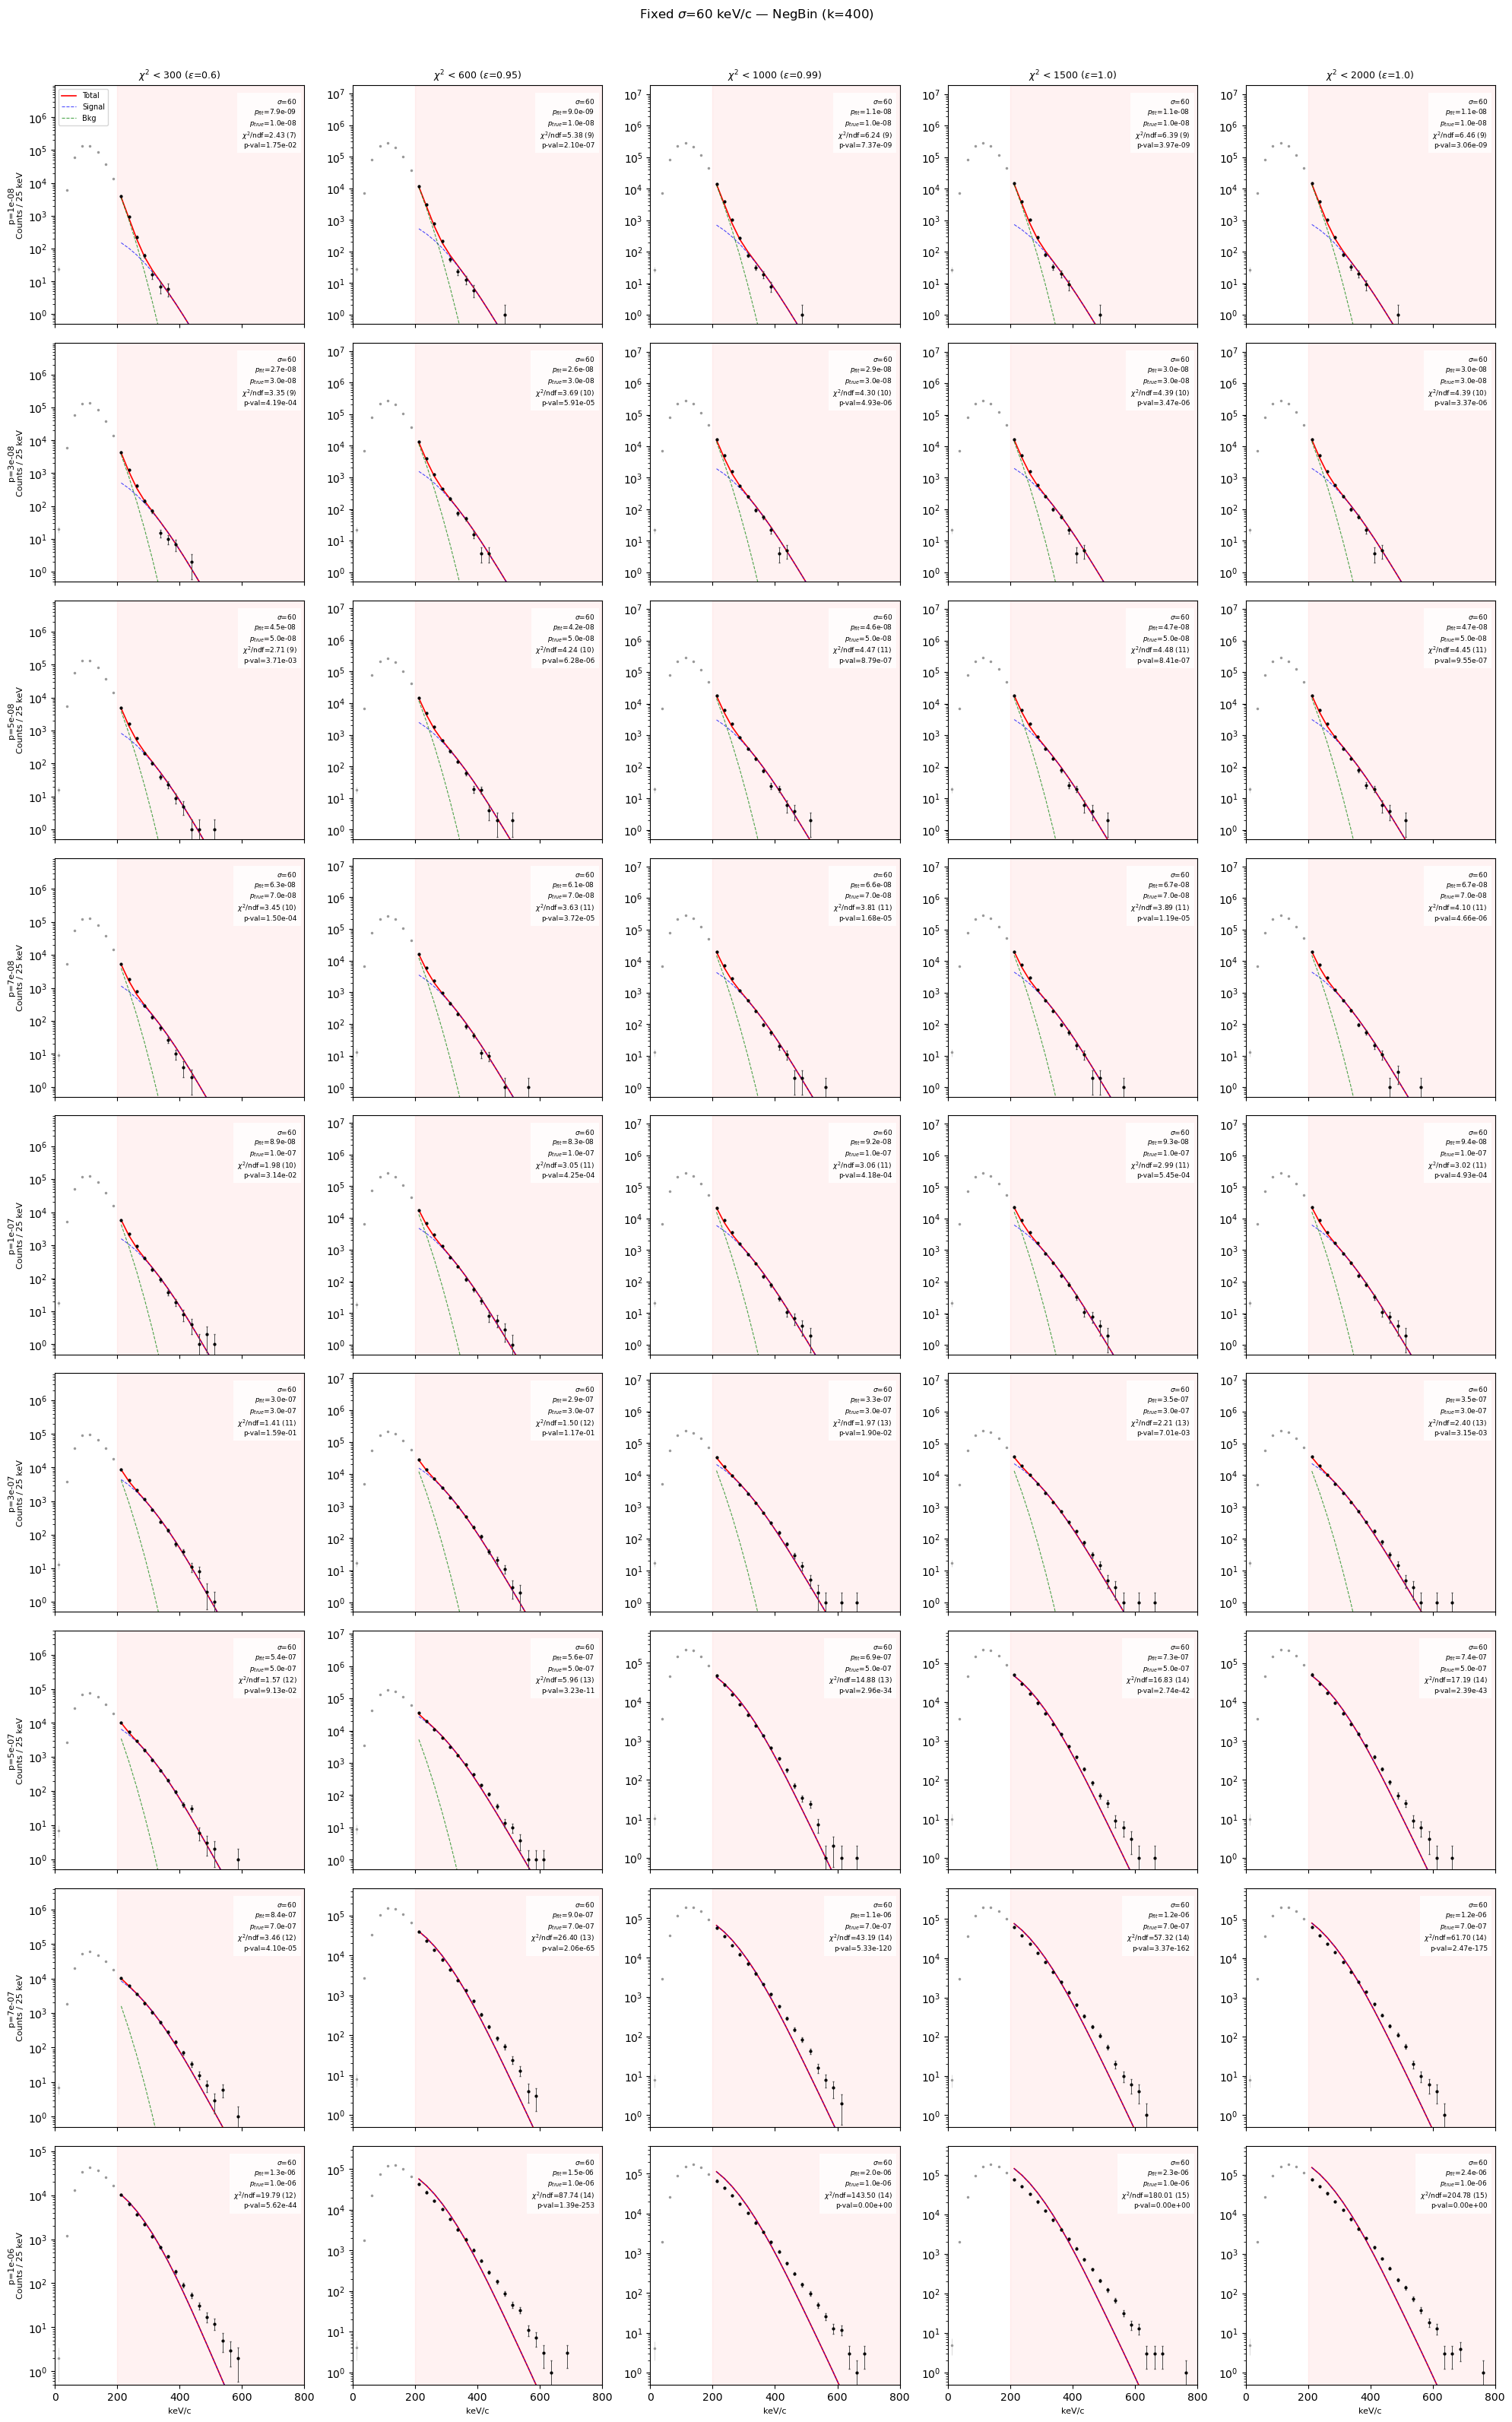

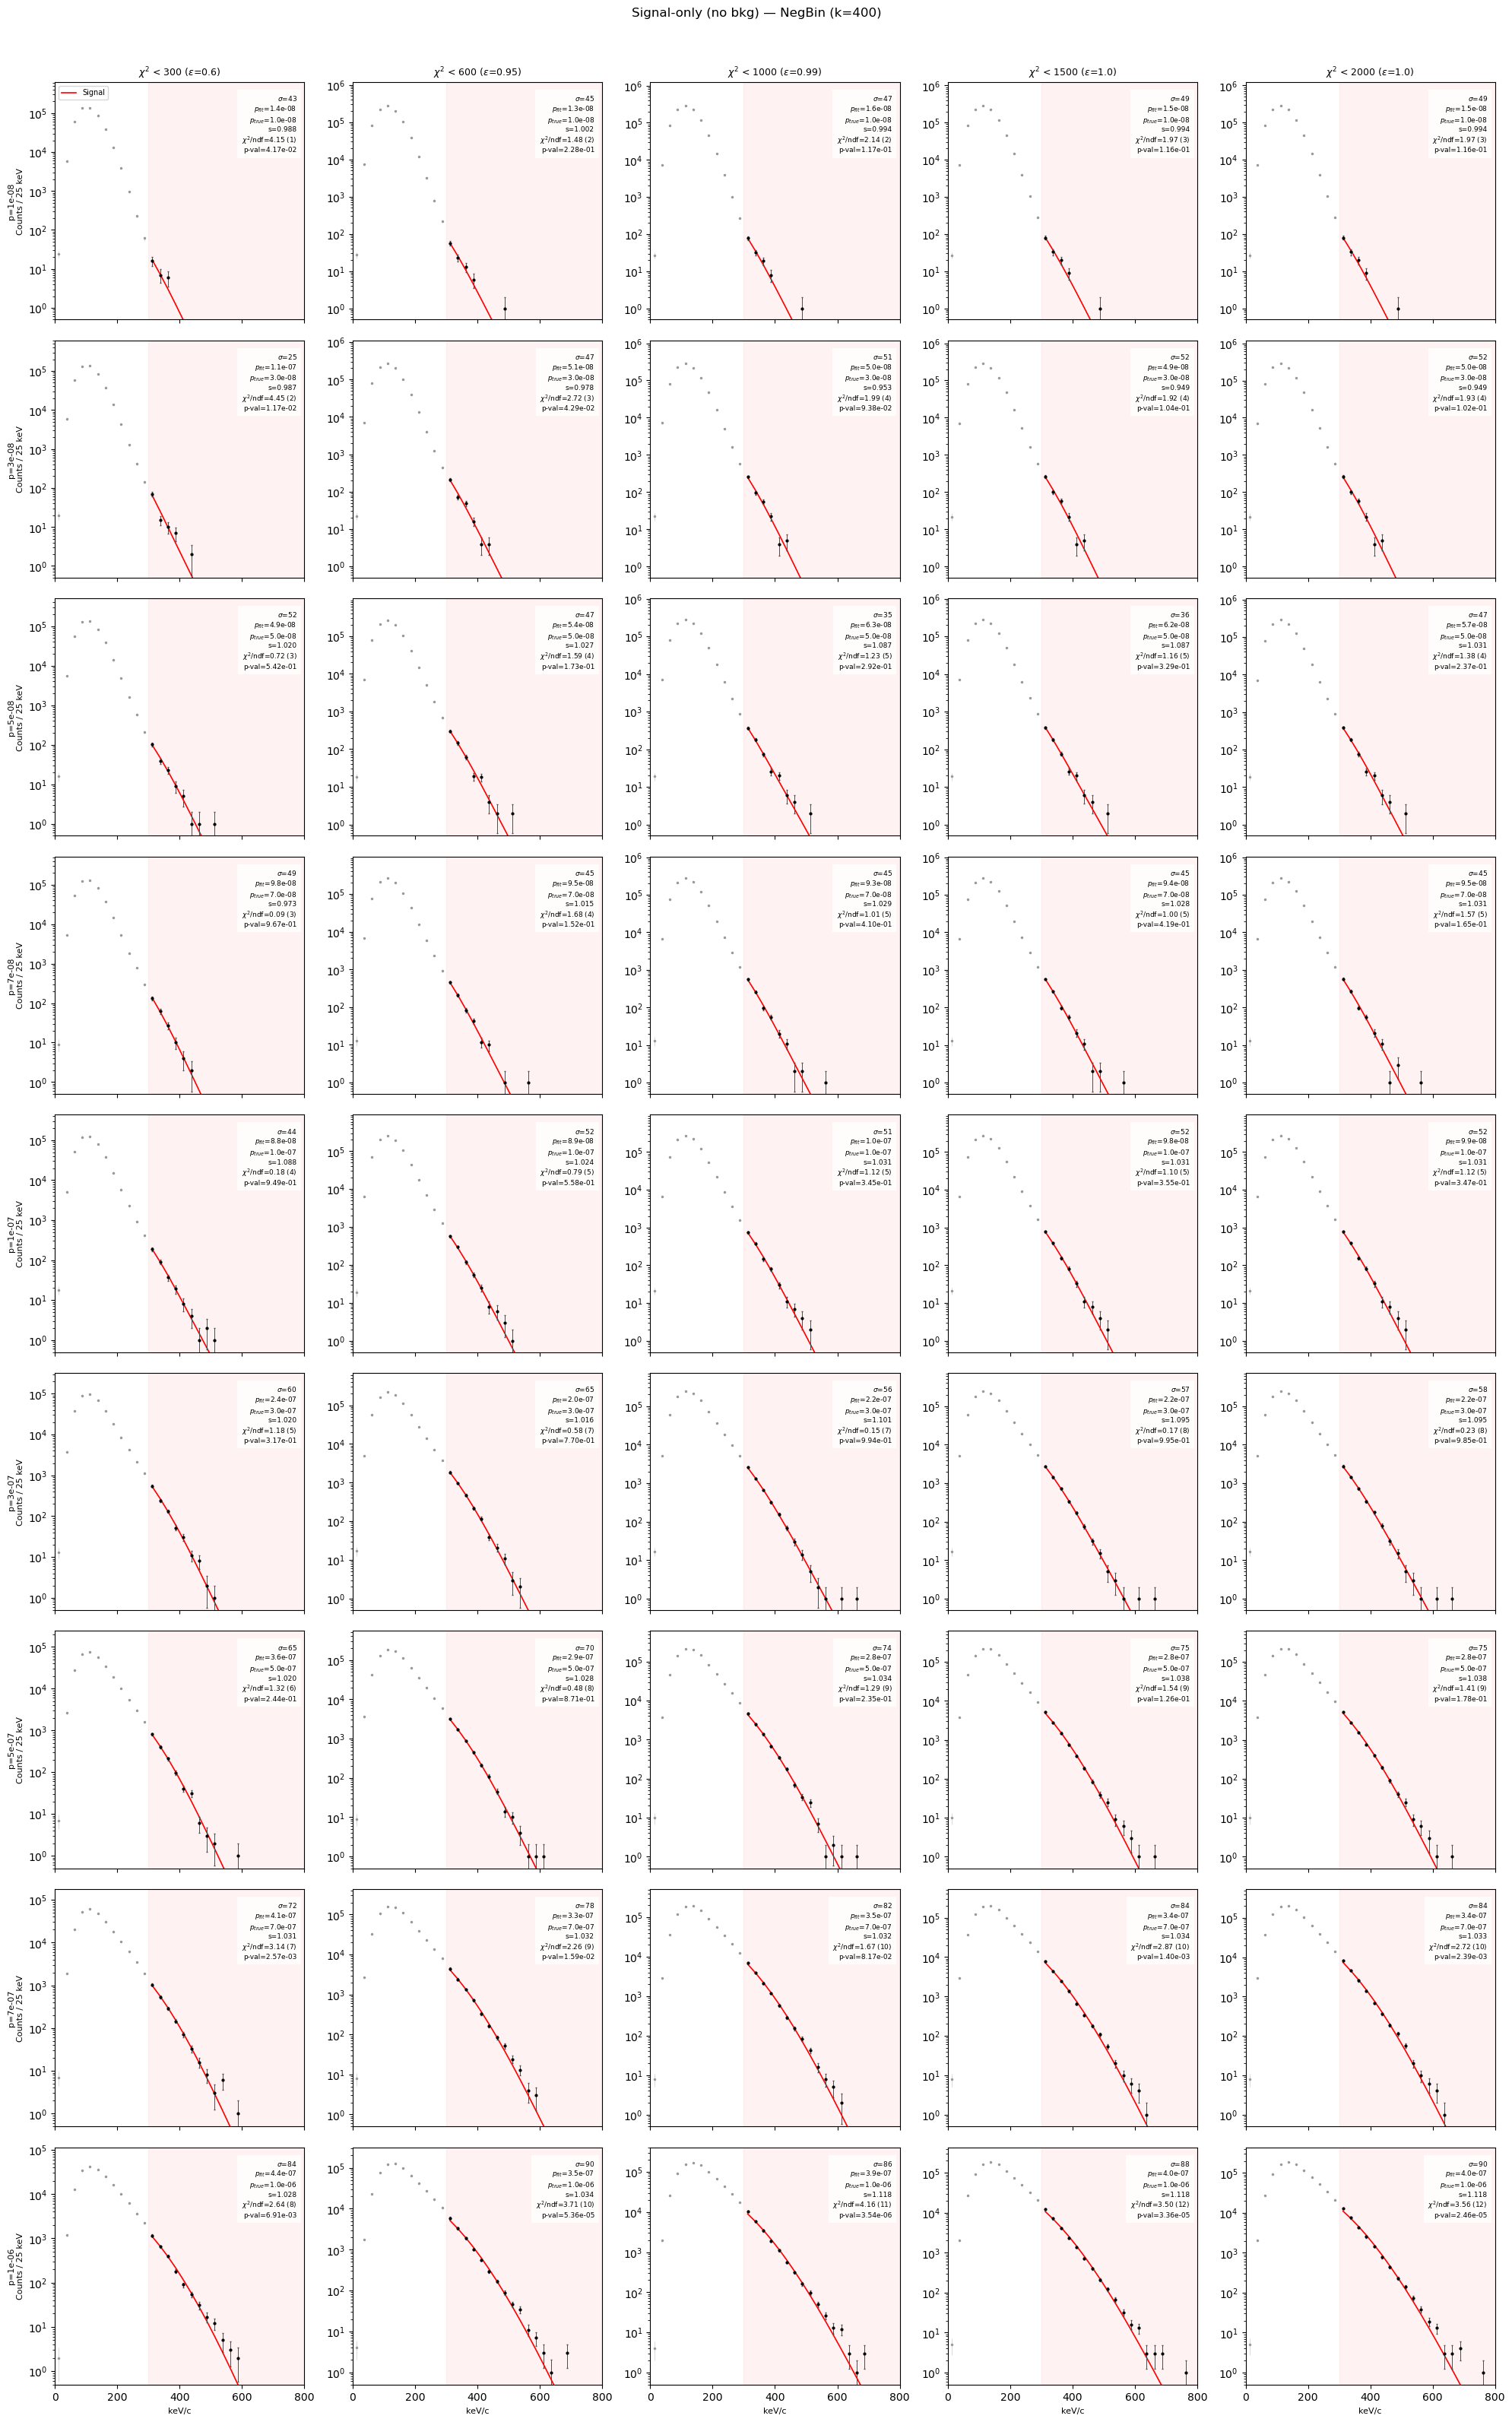

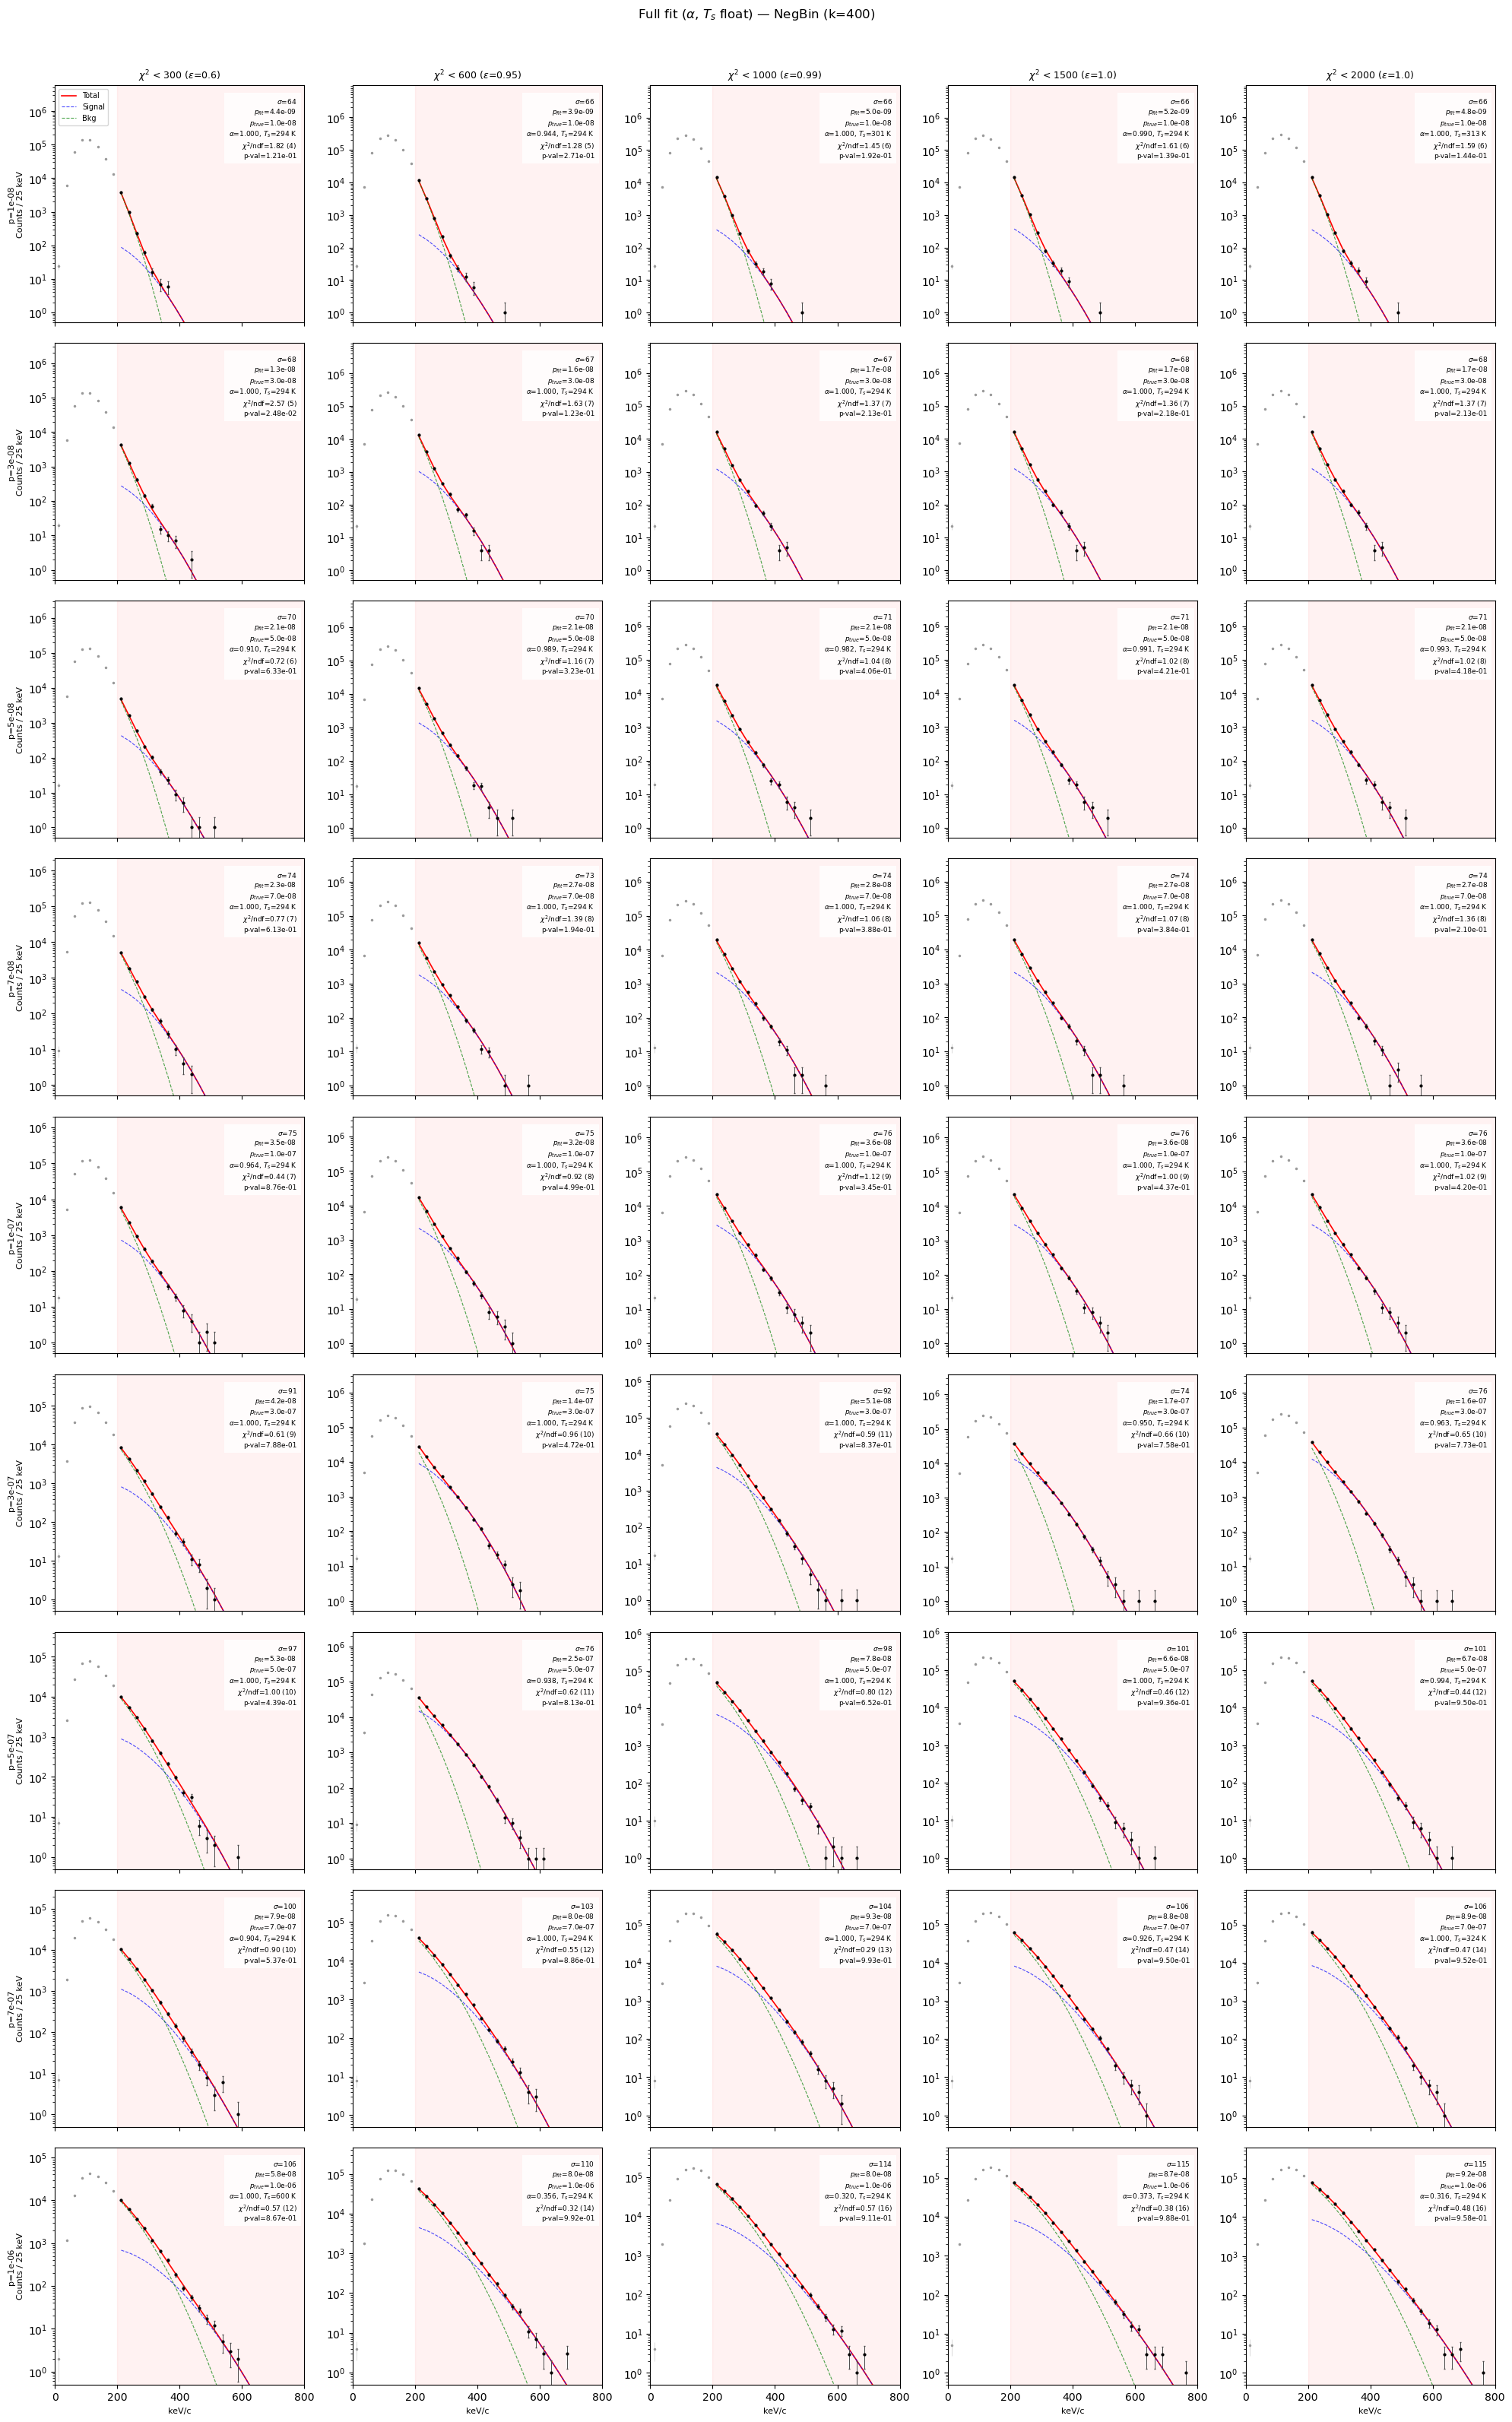

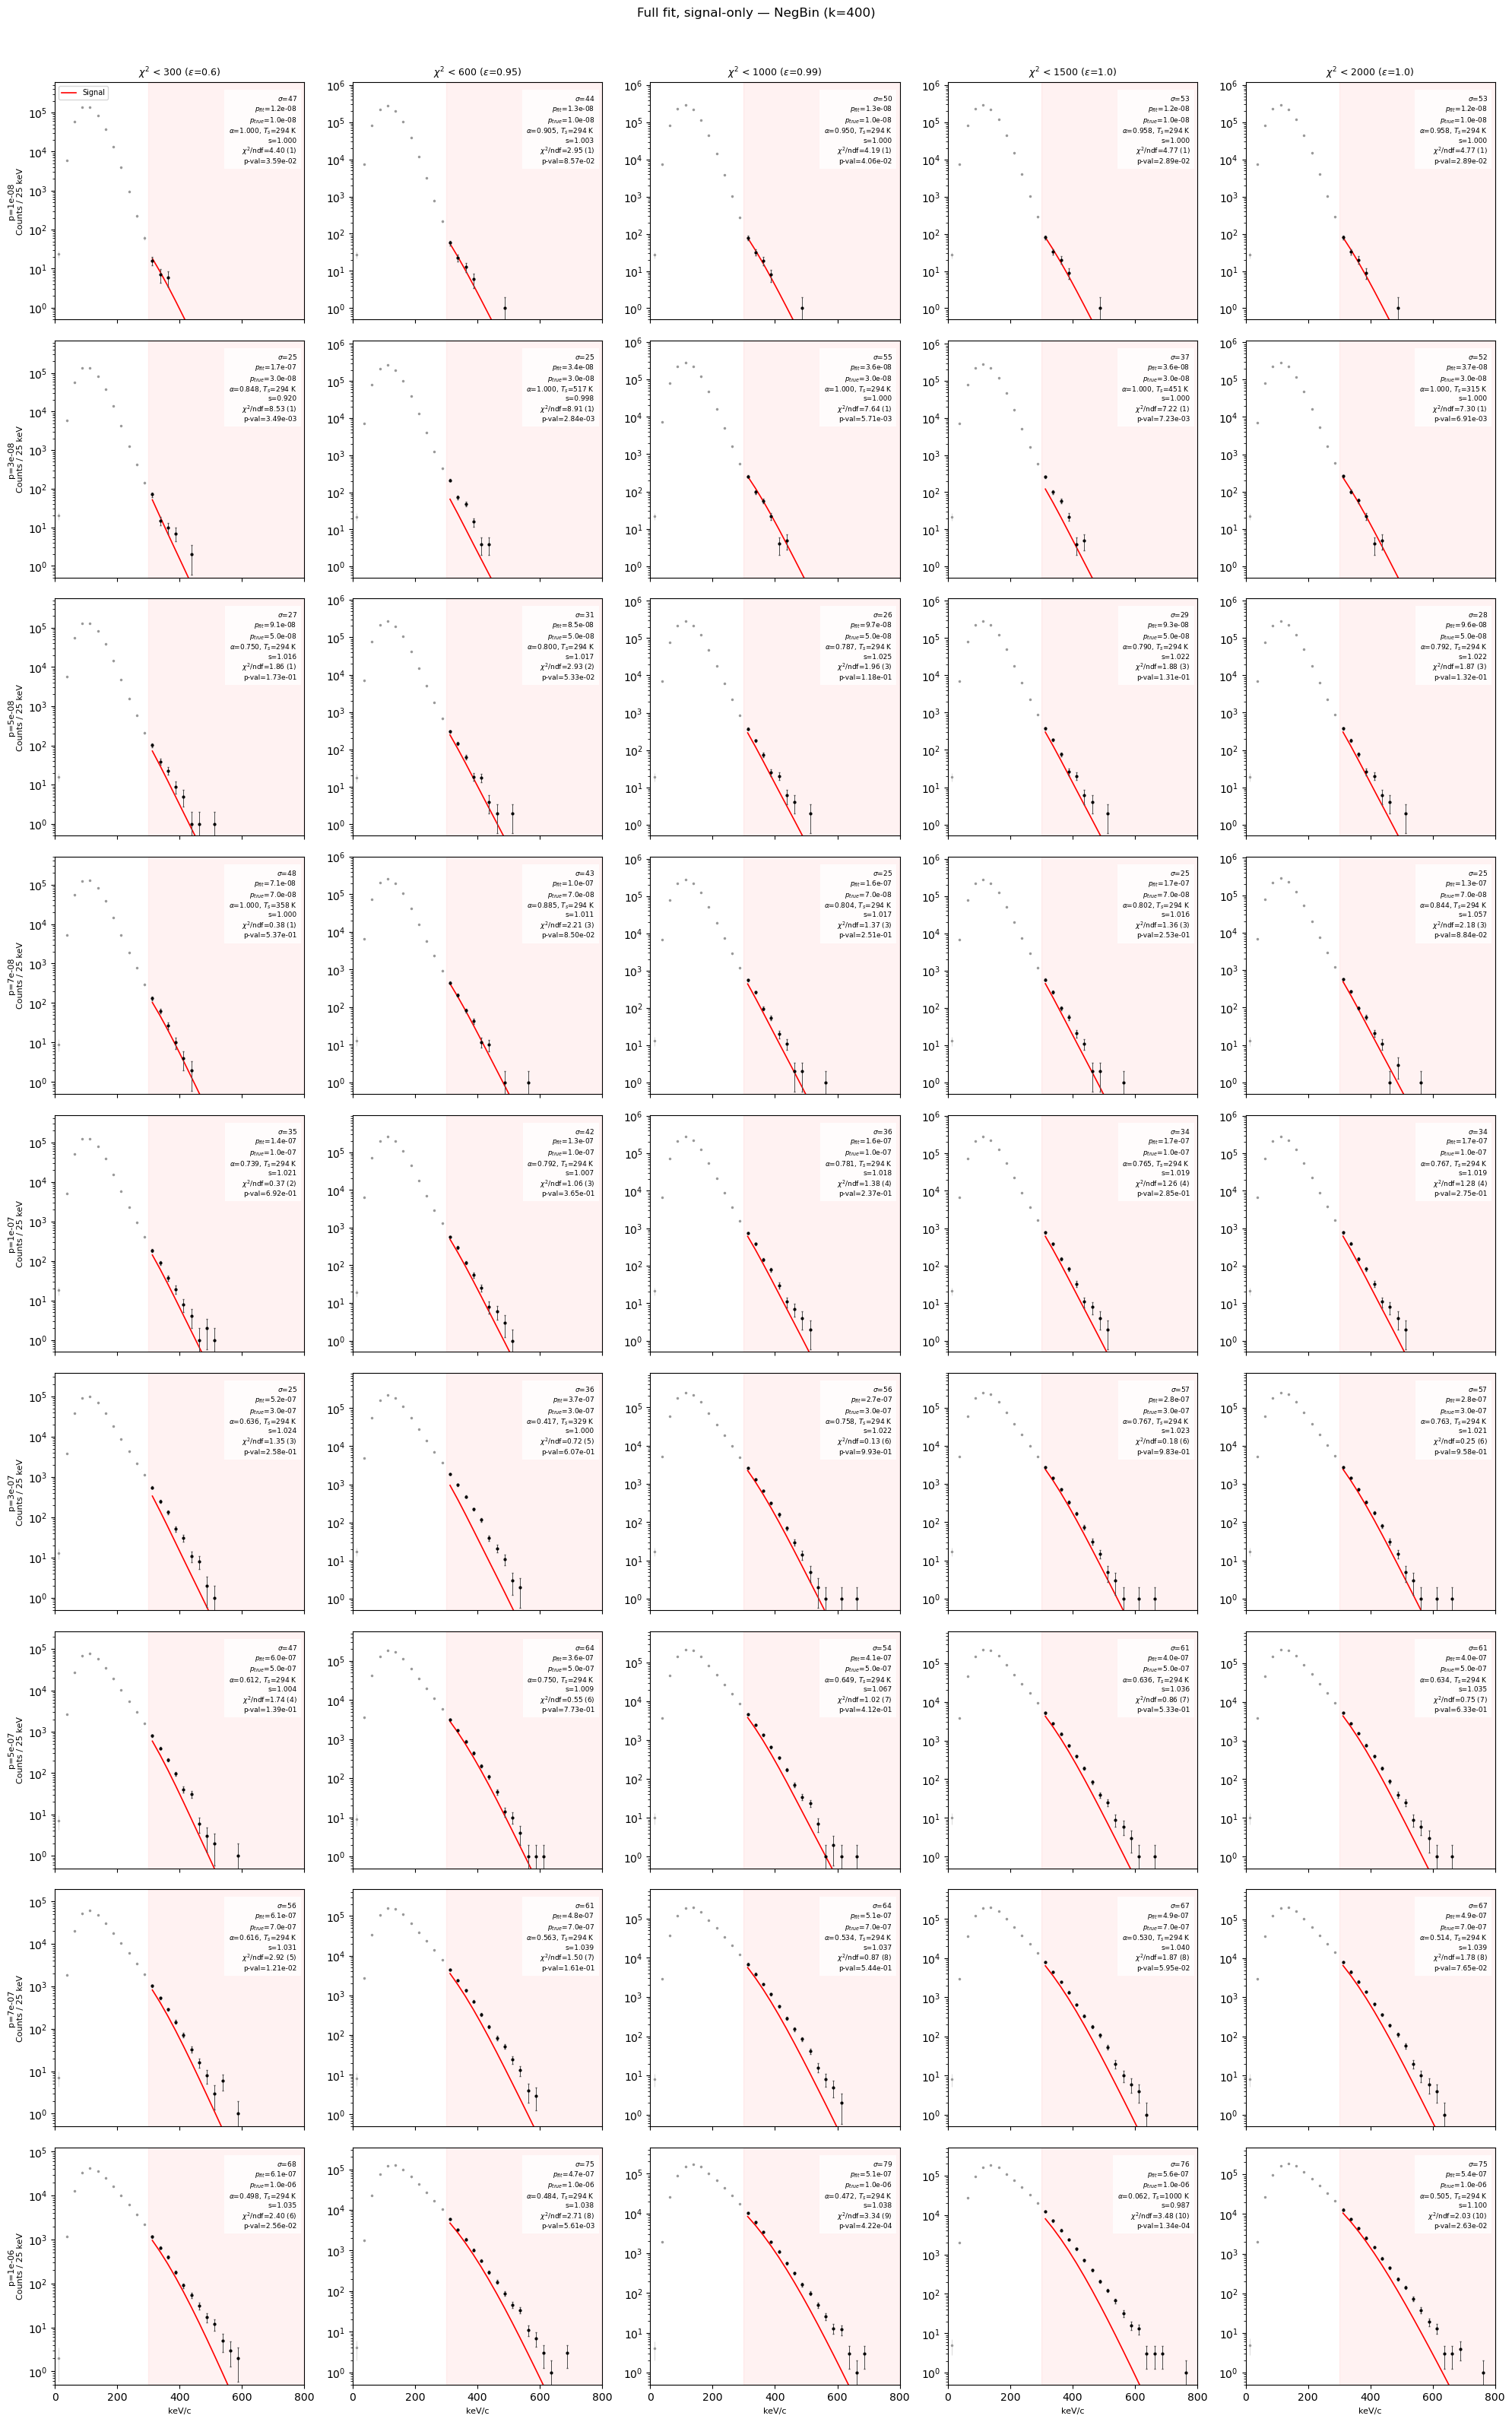

In [32]:
# ── Plot grid for each configuration ──────────────────────────────────────
def plot_fit_grid(cfg_name, results, bc, drdqz_bc, qq_kev, drdqz_unit,
                  k_negbin, scan_configs, drdqz_interp=None, qq_kev_grid=None):
    """Plot pressure (rows) x chi2 threshold (columns) grid for one config."""
    chi2_list = sorted({c for c, _ in results.keys()})
    p_list = sorted({p for _, p in results.keys()})
    nrows, ncols = len(p_list), len(chi2_list)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=True, sharey=False)
    dq = bc[1] - bc[0]

    for i, p in enumerate(p_list):
        for j, chi2_thr in enumerate(chi2_list):
            ax = axes[i, j]
            r = results[(chi2_thr, p)]
            h = r['hist'].astype(float)
            sigma = r['sigma']
            log10_p_fit = r['log10_p']
            amp_s = r['amp_scale']
            alpha_r = r['alpha']
            T_sensor_r = r['T_sensor']
            eff_chi2 = r['eff_chi2']
            band = r['fit_band']
            sig_only = r['signal_only']

            idx_fit = (bc > band[0]) & (bc < band[1])
            bc_fit = bc[idx_fit]

            err_full = np.sqrt(h + h**2 / k_negbin)
            err_fit = np.sqrt(h[idx_fit] + h[idx_fit]**2 / k_negbin)

            ax.errorbar(bc, h, yerr=err_full, fmt='none', ecolor='0.8', elinewidth=0.5, capsize=0)
            ax.plot(bc, h, 'o', ms=1.5, color='0.6')
            ax.errorbar(bc_fit, h[idx_fit], yerr=err_fit, fmt='o', ms=2, color='k',
                        ecolor='0.3', elinewidth=0.7, capsize=1, zorder=5)

            # Use fitted (alpha, T_sensor) for the model curve in full_fit
            if cfg_name == 'full_fit' and not np.isnan(alpha_r) and drdqz_interp is not None:
                drdqz_plot = np.interp(bc, qq_kev_grid, drdqz_interp((alpha_r, T_sensor_r)))
            else:
                drdqz_plot = drdqz_bc

            if amp_s != 1.0:
                drdqz_s = np.interp(bc / amp_s, bc, drdqz_plot) / amp_s
            else:
                drdqz_s = drdqz_plot
            _, drdqzn = calc_gas.smear_drdqz_gauss(bc, drdqz_s, sigma)
            p_scale = 10**(log10_p_fit - (-8))
            h_norm = np.sum(h) * glf.length_search_window * dq
            eff = glf.func_eff(bc, *glf.eff_coefs)
            h_gas = eff_chi2 * eff * drdqzn * p_scale * h_norm

            if sig_only:
                ax.plot(bc_fit, h_gas[idx_fit], 'r-', lw=1.2,
                        label='Signal' if i == 0 and j == 0 else '')
            else:
                gas_in_fit = np.sum(h_gas[idx_fit])
                ntot = np.sum(h[idx_fit]) - gas_in_fit
                bkg = ntot * glf.gaus_normalized(bc_fit, 0, sigma, band) * dq if ntot > 0 else np.zeros_like(bc_fit)
                ax.plot(bc_fit, h_gas[idx_fit] + bkg, 'r-', lw=1.2,
                        label='Total' if i == 0 and j == 0 else '')
                ax.plot(bc_fit, h_gas[idx_fit], 'b--', lw=0.8, alpha=0.7,
                        label='Signal' if i == 0 and j == 0 else '')
                ax.plot(bc_fit, bkg, 'g--', lw=0.8, alpha=0.7,
                        label='Bkg' if i == 0 and j == 0 else '')

            ax.axvspan(band[0], band[1], alpha=0.05, color='red')
            ax.set_yscale('log')
            ax.set_xlim(0, 800)
            ax.set_ylim(bottom=0.5)

            info = (f'$\\sigma$={sigma:.0f}\n'
                    f'$p_{{fit}}$={10**log10_p_fit:.1e}\n$p_{{true}}$={p:.1e}')
            if not np.isnan(alpha_r):
                info += f'\n$\\alpha$={alpha_r:.3f}, $T_s$={T_sensor_r:.0f} K'
            if amp_s != 1.0:
                info += f'\ns={amp_s:.3f}'
            info += f'\n$\\chi^2$/ndf={r["gof_chi2_ndf"]:.2f} ({r["gof_ndof"]})\np-val={r["gof_pval"]:.2e}'
            ax.text(0.97, 0.95, info, transform=ax.transAxes, va='top', ha='right',
                    fontsize=6.5, bbox=dict(fc='white', alpha=0.8, ec='none'))

            if i == 0:
                ax.set_title(f'$\\chi^2$ < {chi2_thr} ($\\varepsilon$={eff_chi2})', fontsize=9)
            if j == 0:
                ax.set_ylabel(f'p={p:.0e}\nCounts / 25 keV', fontsize=8)
            if i == nrows - 1:
                ax.set_xlabel('keV/c', fontsize=8)

    axes[0, 0].legend(fontsize=7, loc='upper left')
    fig.suptitle(f'{scan_configs[cfg_name]} — NegBin (k={k_negbin:.0f})', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

for cfg_name in scan_configs:
    plot_fit_grid(cfg_name, all_results[cfg_name], bc, drdqz_bc, qq_kev, drdqz_unit,
                  k_negbin, scan_configs,
                  drdqz_interp=drdqz_interp, qq_kev_grid=qq_kev_grid)

## Summary: pressure recovery across configurations

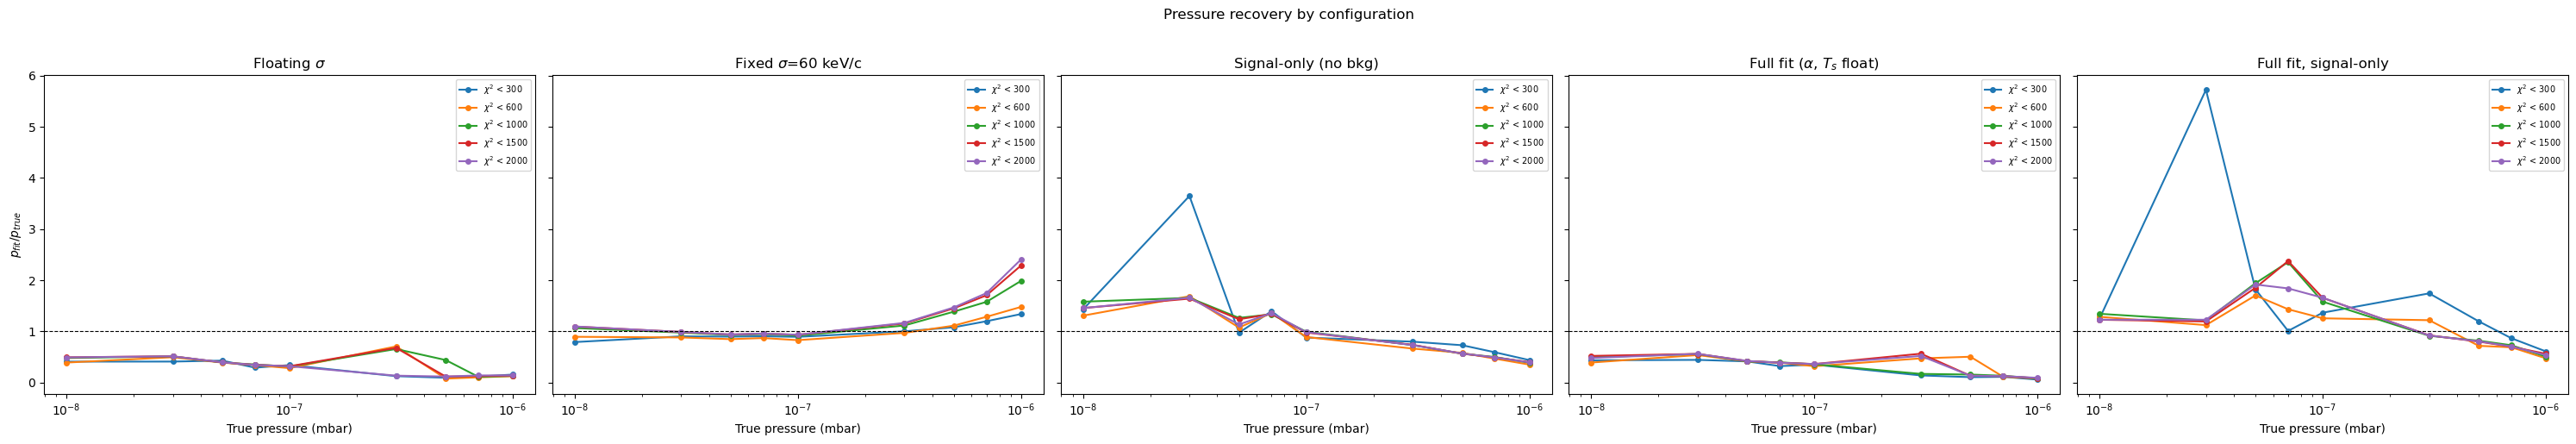

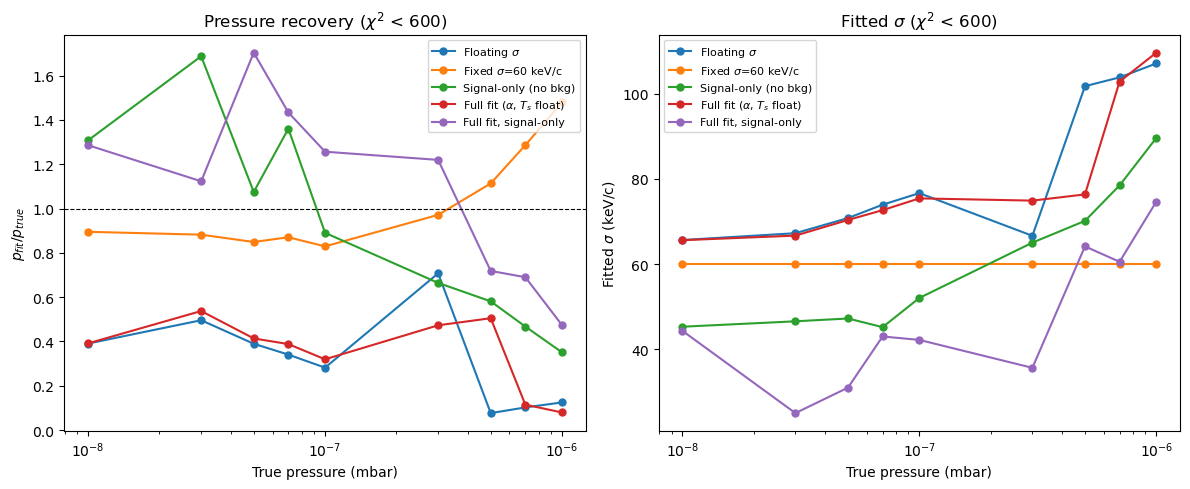

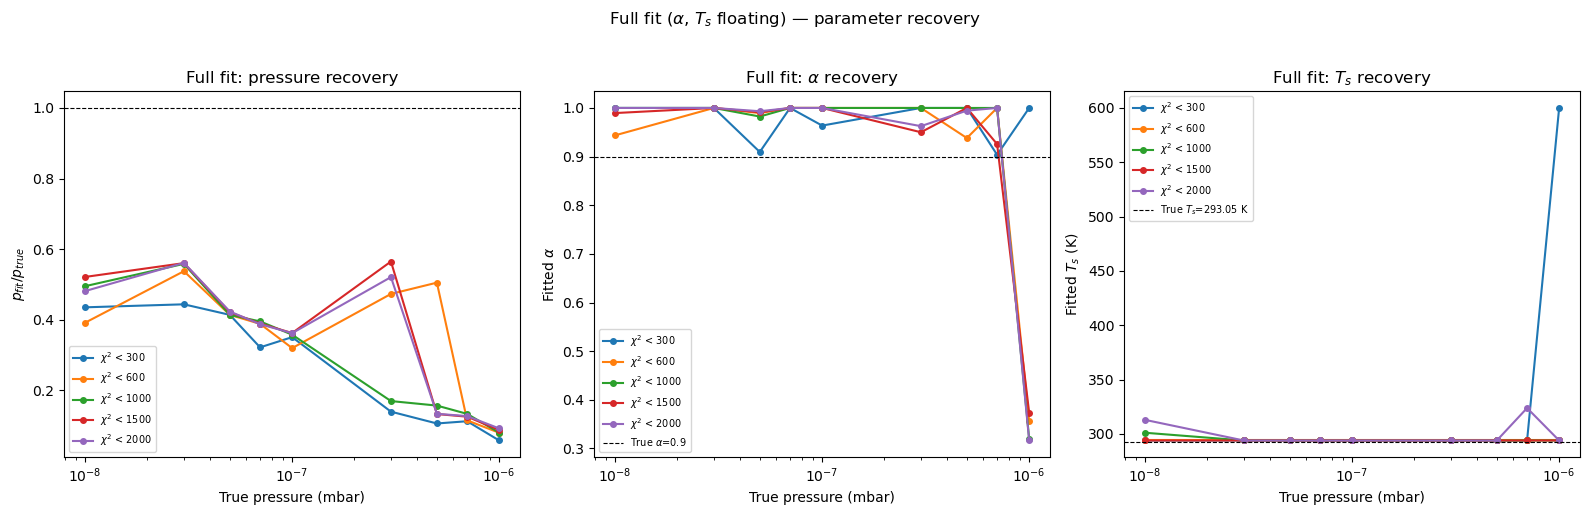

In [33]:
# ── p_fit / p_true per chi2 threshold, one panel per config ───────────────
fig, axes = plt.subplots(1, len(scan_configs), figsize=(6 * len(scan_configs), 5), sharey=True)
p_true = np.array(all_pressures)

for ax, (cfg_name, cfg_label) in zip(axes, scan_configs.items()):
    res = all_results[cfg_name]
    for chi2_thr in chi2_thresholds:
        p_fit = np.array([10**res[(chi2_thr, p)]['log10_p'] for p in all_pressures])
        ax.plot(p_true, p_fit / p_true, 'o-', ms=4, label=f'$\\chi^2$ < {chi2_thr}')
    ax.axhline(1, color='k', ls='--', lw=0.8)
    ax.set_xscale('log')
    ax.set_xlabel('True pressure (mbar)')
    ax.set_title(cfg_label)
    ax.legend(fontsize=7)
axes[0].set_ylabel('$p_{fit} / p_{true}$')
plt.suptitle('Pressure recovery by configuration', y=1.02)
plt.tight_layout()
plt.show()

# ── Cross-config comparison at chi2=600 ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
chi2_ref = 600

ax = axes[0]
for cfg_name, cfg_label in scan_configs.items():
    res = all_results[cfg_name]
    p_fit = np.array([10**res[(chi2_ref, p)]['log10_p'] for p in all_pressures])
    ax.plot(p_true, p_fit / p_true, 'o-', ms=5, label=cfg_label)
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('True pressure (mbar)')
ax.set_ylabel('$p_{fit} / p_{true}$')
ax.legend(fontsize=8)
ax.set_title(f'Pressure recovery ($\\chi^2$ < {chi2_ref})')

ax = axes[1]
for cfg_name, cfg_label in scan_configs.items():
    res = all_results[cfg_name]
    sigmas = [res[(chi2_ref, p)]['sigma'] for p in all_pressures]
    ax.plot(all_pressures, sigmas, 'o-', ms=5, label=cfg_label)
ax.set_xscale('log')
ax.set_xlabel('True pressure (mbar)')
ax.set_ylabel('Fitted $\\sigma$ (keV/c)')
ax.legend(fontsize=8)
ax.set_title(f'Fitted $\\sigma$ ($\\chi^2$ < {chi2_ref})')

plt.tight_layout()
plt.show()

# ── Full fit: alpha and T_sensor recovery ─────────────────────────────────
res_ff = all_results['full_fit']
mc_alpha_true = mc_meta['mc_alpha']
mc_T_sensor_true = mc_meta['mc_T_sensor']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for chi2_thr in chi2_thresholds:
    p_fit = np.array([10**res_ff[(chi2_thr, p)]['log10_p'] for p in all_pressures])
    ax.plot(p_true, p_fit / p_true, 'o-', ms=4, label=f'$\\chi^2$ < {chi2_thr}')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('True pressure (mbar)')
ax.set_ylabel('$p_{fit} / p_{true}$')
ax.legend(fontsize=7)
ax.set_title('Full fit: pressure recovery')

ax = axes[1]
for chi2_thr in chi2_thresholds:
    alphas = [res_ff[(chi2_thr, p)]['alpha'] for p in all_pressures]
    ax.plot(all_pressures, alphas, 'o-', ms=4, label=f'$\\chi^2$ < {chi2_thr}')
ax.axhline(mc_alpha_true, color='k', ls='--', lw=0.8, label=f'True $\\alpha$={mc_alpha_true}')
ax.set_xscale('log')
ax.set_xlabel('True pressure (mbar)')
ax.set_ylabel('Fitted $\\alpha$')
ax.legend(fontsize=7)
ax.set_title('Full fit: $\\alpha$ recovery')

ax = axes[2]
for chi2_thr in chi2_thresholds:
    ts_vals = [res_ff[(chi2_thr, p)]['T_sensor'] for p in all_pressures]
    ax.plot(all_pressures, ts_vals, 'o-', ms=4, label=f'$\\chi^2$ < {chi2_thr}')
ax.axhline(mc_T_sensor_true, color='k', ls='--', lw=0.8, label=f'True $T_s$={mc_T_sensor_true} K')
ax.set_xscale('log')
ax.set_xlabel('True pressure (mbar)')
ax.set_ylabel('Fitted $T_s$ (K)')
ax.legend(fontsize=7)
ax.set_title('Full fit: $T_s$ recovery')

plt.suptitle('Full fit ($\\alpha$, $T_s$ floating) — parameter recovery', y=1.02)
plt.tight_layout()
plt.show()